In [1]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [2]:
data = np.load("wesad_balanced_multiwindow.npz")
X, y = data["X"], data["y"]

In [3]:
print(X[0].shape, y[0].shape)  # (3, 3000, 1) (3, 3000)

(512, 11) ()


In [4]:
print(y[24])

1


In [8]:
class WESADDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)  # [B, T, D]
        self.y = torch.tensor(y, dtype=torch.long)     # [B]
    
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [9]:
def split_dataset(X, y, test_size=0.2, val_size=0.25, random_state=42):
    """
    Splits dataset into train/val/test sets with stratification.
    """
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=val_size, stratify=y_temp, random_state=random_state)

    summary = pd.DataFrame({
        'Split': ['Train', 'Validation', 'Test'],
        'Total': [len(y_train), len(y_val), len(y_test)],
        'Class 0': [np.sum(y_train == 0), np.sum(y_val == 0), np.sum(y_test == 0)],
        'Class 1': [np.sum(y_train == 1), np.sum(y_val == 1), np.sum(y_test == 1)],
    })

    return (X_train, y_train), (X_val, y_val), (X_test, y_test), summary

In [10]:
(X_train, y_train), (X_val, y_val),(X_test,y_test),summary= split_dataset(X, y, test_size=0.2, val_size=0.25, random_state=42)

train_dataset = WESADDataset(X_train, y_train)
val_dataset = WESADDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [5]:
import torch
import torch.nn as nn

class ModalityCNN1D(nn.Module):
    def __init__(self, input_channels, embed_dim=128):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_channels, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # [B, 128, 1]
        )
        self.project = nn.Linear(128, embed_dim)

    def forward(self, x):  # x: [B, T, C]
        x = x.permute(0, 2, 1)  # [B, C, T] for Conv1d
        x = self.cnn(x)         # [B, 128, 1]
        x = x.squeeze(-1)       # [B, 128]
        x = self.project(x)     # [B, embed_dim]
        return x


In [6]:
class MultimodalCNN1D(nn.Module):
    def __init__(self, modality_dims, embed_dim=128, num_classes=3):
        super().__init__()
        self.modalities = nn.ModuleDict({
            name: ModalityCNN1D(input_channels=dim, embed_dim=embed_dim)
            for name, dim in modality_dims.items()
        })

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * len(modality_dims), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):  # x: [B, T, D]
        embeddings = []
        for name, module in self.modalities.items():
            idx = self._modality_indices[name]
            x_mod = x[:, :, idx]  # [B, T, specific_feature_dim]
            embeddings.append(module(x_mod))  # [B, embed_dim]
        concat_embeds = torch.cat(embeddings, dim=1)  # [B, embed_dim * modalities]
        return self.classifier(concat_embeds)

    @property
    def _modality_indices(self):
        return {
            'ACC': slice(0, 3),
            'EDA': slice(3, 4),
            'TEMP': slice(4, 5),
            'Resp': slice(5, 6),
            'BVP': slice(6, 11)
        }


In [7]:
modality_dims = {
    'ACC': 3, 'EDA': 1, 'TEMP': 1, 'Resp': 1, 'BVP': 5
}

model = MultimodalCNN1D(modality_dims=modality_dims, embed_dim=128, num_classes=3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


MultimodalCNN1D(
  (modalities): ModuleDict(
    (ACC): ModalityCNN1D(
      (cnn): Sequential(
        (0): Conv1d(3, 64, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU()
        (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): ReLU()
        (5): AdaptiveAvgPool1d(output_size=1)
      )
      (project): Linear(in_features=128, out_features=128, bias=True)
    )
    (EDA): ModalityCNN1D(
      (cnn): Sequential(
        (0): Conv1d(1, 64, kernel_size=(5,), stride=(1,), padding=(2,))
        (1): ReLU()
        (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
        (4): ReLU()
        (5): AdaptiveAvgPool1d(output_size=1)
      )
      (project): Linear(in_features=128, out_features=128, bias=True)
    )
    (TEMP): ModalityCNN1D(
      (cnn): Seque

In [11]:
def train(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss, correct = 0, 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(dataloader.dataset), correct / len(dataloader.dataset)

In [12]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * X.size(0)
            correct += (out.argmax(1) == y).sum().item()
    return total_loss / len(dataloader.dataset), correct / len(dataloader.dataset)

In [13]:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()

In [14]:
for epoch in range(10):
    train_loss, train_acc = train(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

Epoch 01 | Train Loss: 0.1012 | Acc: 0.9666 | Val Loss: 0.0099 | Acc: 0.9968
Epoch 02 | Train Loss: 0.0057 | Acc: 0.9987 | Val Loss: 0.0045 | Acc: 0.9984
Epoch 03 | Train Loss: 0.0031 | Acc: 0.9993 | Val Loss: 0.0024 | Acc: 0.9993
Epoch 04 | Train Loss: 0.0023 | Acc: 0.9994 | Val Loss: 0.0025 | Acc: 0.9992
Epoch 05 | Train Loss: 0.0017 | Acc: 0.9996 | Val Loss: 0.0011 | Acc: 0.9995
Epoch 06 | Train Loss: 0.0016 | Acc: 0.9995 | Val Loss: 0.0021 | Acc: 0.9994
Epoch 07 | Train Loss: 0.0015 | Acc: 0.9995 | Val Loss: 0.0005 | Acc: 0.9999
Epoch 08 | Train Loss: 0.0016 | Acc: 0.9995 | Val Loss: 0.0006 | Acc: 0.9998
Epoch 09 | Train Loss: 0.0012 | Acc: 0.9997 | Val Loss: 0.0006 | Acc: 0.9998
Epoch 10 | Train Loss: 0.0012 | Acc: 0.9997 | Val Loss: 0.0013 | Acc: 1.0000


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [16]:
def evaluate_infer(model, loader, criterion, device, print_report=False):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            total_loss += loss.item() * X.size(0)
            correct += (out.argmax(1) == y).sum().item()

            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    if print_report:
        print("\n📊 Classification Report:")
        print(classification_report(all_labels, all_preds, digits=4))

        print("\n🧮 Confusion Matrix:")
        cm = confusion_matrix(all_labels, all_preds)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title("Confusion Matrix")
        plt.show()

    return total_loss / len(loader.dataset), correct / len(loader.dataset)


📊 Classification Report:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      7452
           1     1.0000    1.0000    1.0000      7452

    accuracy                         1.0000     14904
   macro avg     1.0000    1.0000    1.0000     14904
weighted avg     1.0000    1.0000    1.0000     14904


🧮 Confusion Matrix:


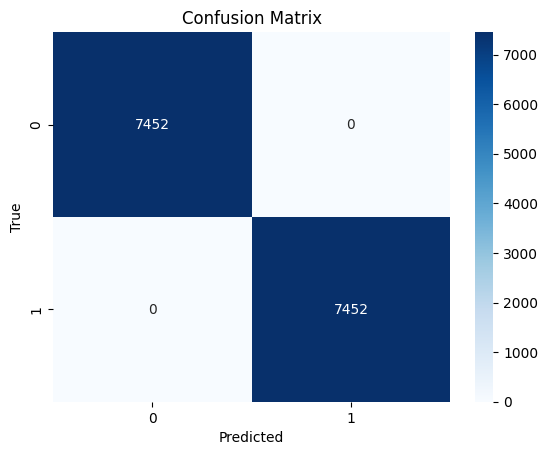

(0.001259148467956584, 1.0)

In [17]:
evaluate_infer(model, val_loader, criterion, device, print_report=True)

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [21]:
def plot_binary_roc(model, dataloader, device):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            outputs = model(X)
            probs = torch.softmax(outputs, dim=1)[:, 1]  # Get probability for class 1 (positive class)
            all_labels.append(y.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_probs = np.concatenate(all_probs)

    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.05, 1.05])
    plt.ylim([-0.05, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Binary ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

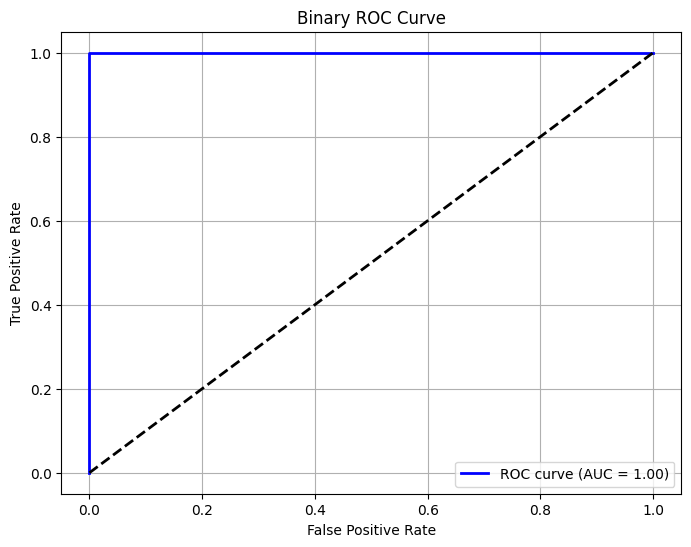

In [22]:
plot_binary_roc(model, val_loader, device)